# AAPL Quantitative Trading Strategy

## Moving Average Crossover Strategy with Backtesting and Walk-Forward Validation

This project develops a systematic trading strategy using AAPL historical price data. The strategy uses technical indicators, portfolio simulation, risk analysis, transaction cost modeling, and out-of-sample validation to evaluate performance.

## 2. Technology Stack

This project uses Python and several financial data science libraries to build a quantitative trading backtesting system.

### Python
Python is the primary programming language used for:
- Data analysis
- Strategy development
- Financial calculations
- Backtesting algorithms
- Visualization

### pandas
Used for:
- Organizing financial data into DataFrames
- Cleaning historical price data
- Calculating returns and indicators

### NumPy
Used for:
- Numerical calculations
- Statistical analysis
- Efficient mathematical operations

### Matplotlib
Used for:
- Creating charts
- Visualizing stock prices
- Displaying trading signals
- Plotting portfolio performance

### yfinance
Used for:
- Downloading historical stock market data from Yahoo Finance
- Accessing daily prices, volume, and market information

### QuantStats
Used for:
- Generating financial performance reports
- Calculating metrics such as:
  - Sharpe Ratio
  - Drawdown
  - Volatility
  - Returns analysis

### SciPy
Used for:
- Statistical analysis
- Optimization methods
- Advanced quantitative modeling

These tools combine to create a complete quantitative research workflow similar to the process used by professional traders and investment firms.

## 1. Project Overview: Systematic Trading Strategy Backtester with Walk-Forward Validation

This project aims to build a professional-grade Python backtesting system capable of evaluating systematic trading strategies using historical market data. It is designed to be comprehensive enough for a finance resume and GitHub portfolio.

### What this Project Does

This system will allow us to:
1.  **Collect Historical Data**: Download and manage historical stock price data from various sources.
2.  **Develop Trading Strategies**: Implement and test different quantitative trading strategies (e.g., Moving Average Crossover, Mean Reversion).
3.  **Generate Trading Signals**: Convert strategy rules into actionable buy/sell signals.
4.  **Simulate Trading**: Run a backtesting engine that simulates trades based on generated signals, incorporating realistic features like transaction costs and slippage.
5.  **Analyze Performance**: Calculate key financial risk and performance metrics (e.g., Sharpe Ratio, Max Drawdown, CAGR).
6.  **Validate Robustness**: Employ walk-forward validation to ensure the strategy's robustness and prevent overfitting.
7.  **Visualize Results**: Create a comprehensive dashboard for visualizing strategy performance, equity curves, and drawdowns.

### Why Quantitative Traders Use Backtesting Systems

Quantitative traders rely on backtesting systems to rigorously test their trading ideas and strategies against historical data before deploying them in live markets. It provides a controlled environment to:
*   **Evaluate Profitability**: Determine if a strategy has generated positive returns historically.
*   **Assess Risk**: Understand the potential risks, such as maximum drawdowns and volatility.
*   **Optimize Parameters**: Fine-tune strategy parameters to potentially improve performance.
*   **Build Confidence**: Gain confidence in a strategy's efficacy and robustness.

### How Hedge Funds Use Similar Systems

Hedge funds and other institutional investors use sophisticated backtesting systems as a core component of their research and development process. These systems are often highly customized and integrated into larger quantitative pipelines. They use them to:
*   **Develop Alpha Strategies**: Research and develop proprietary trading algorithms.
*   **Risk Management**: Quantify and manage the risk exposure of their portfolios.
*   **Portfolio Construction**: Inform decisions about asset allocation and position sizing.
*   **Compliance and Reporting**: Provide data for internal and external reporting and regulatory compliance.
*   **Prevent Overfitting**: Advanced validation techniques like walk-forward analysis are crucial to ensure strategies perform well on unseen data, rather than just on the data they were developed with.

### Skills This Demonstrates for a Finance Internship/Resume

Building this project demonstrates a strong skill set valuable for roles in quantitative finance, algorithmic trading, and data science, including:
*   **Python Programming**: Proficiency in data manipulation, algorithmic development, and object-oriented programming.
*   **Quantitative Analysis**: Ability to apply statistical and mathematical concepts to financial data.
*   **Financial Market Knowledge**: Understanding of trading concepts, strategies, and market dynamics.
*   **Data Science & Engineering**: Skills in data collection, cleaning, and preparation.
*   **Backtesting & Validation**: Expertise in designing and executing robust backtesting methodologies, including advanced validation techniques.
*   **Performance & Risk Metrics**: Knowledge of key financial performance and risk indicators.
*   **Data Visualization**: Ability to effectively communicate complex financial insights through visualizations.
*   **Software Development Practices**: Writing clean, modular, and well-documented code suitable for collaborative environments.

In [1]:
!pip install yfinance quantstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.2 MB/s eta 0:00:00


In [2]:
# 3. Import Libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import quantstats as qs

print("Libraries loaded successfully")

Libraries loaded successfully


# 4. Data Collection

This section downloads historical stock price data that will be used to test trading strategies.

In [3]:
# Download Historical Stock Data

ticker = "AAPL"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

data.head()

/tmp/ipykernel_1906/1954545397.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


# 5. Data Cleaning and Preparation

This section prepares the stock data for analysis by removing missing values and checking the dataset structure.

In [4]:
# Check dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2516 non-null   float64
 1   (High, AAPL)    2516 non-null   float64
 2   (Low, AAPL)     2516 non-null   float64
 3   (Open, AAPL)    2516 non-null   float64
 4   (Volume, AAPL)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [5]:
# Check for missing values

data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [6]:
# Remove missing values

data = data.dropna()

data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


# 6. Strategy Development

This section creates a moving average crossover trading strategy.

The strategy buys when short-term momentum becomes stronger than long-term momentum and exits when momentum weakens.

In [7]:
# Create Moving Averages

data["50_MA"] = data["Close"].rolling(window=50).mean()
data["200_MA"] = data["Close"].rolling(window=200).mean()

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816


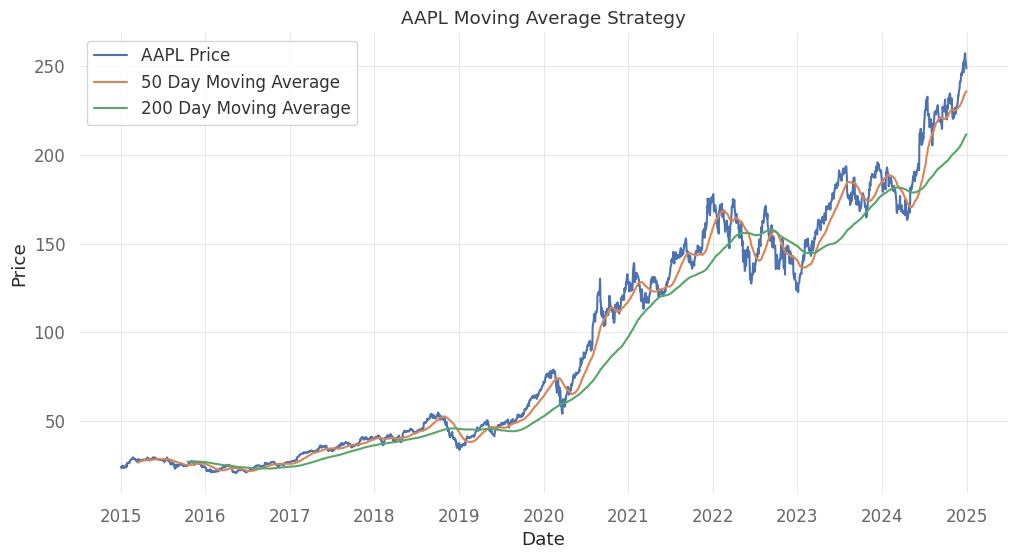

In [8]:
# Plot Moving Averages

plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="AAPL Price")
plt.plot(data["50_MA"], label="50 Day Moving Average")
plt.plot(data["200_MA"], label="200 Day Moving Average")

plt.title("AAPL Moving Average Strategy")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

# 7. Trading Signal Generation

This section converts the moving average strategy into trading signals.

A value of 1 means we hold the stock.
A value of 0 means we are out of the market.

In [9]:
# Create Trading Signals

data["Signal"] = 0

data.loc[data["50_MA"] > data["200_MA"], "Signal"] = 1

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1


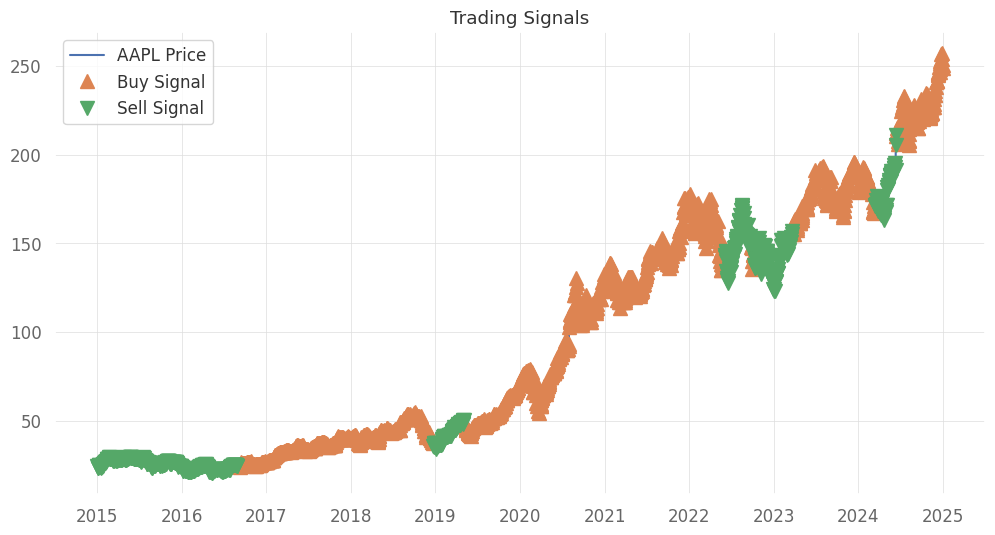

In [10]:
# Plot Buy/Sell Signals

plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="AAPL Price")

plt.plot(
    data[data["Signal"] == 1].index,
    data["Close"][data["Signal"] == 1],
    "^",
    markersize=10,
    label="Buy Signal"
)

plt.plot(
    data[data["Signal"] == 0].index,
    data["Close"][data["Signal"] == 0],
    "v",
    markersize=10,
    label="Sell Signal"
)

plt.title("Trading Signals")
plt.legend()
plt.show()

# 8. Backtesting Engine

This section simulates trading using the generated signals.

The portfolio starts with $10,000 and tracks how the strategy performs over time.

In [11]:
# Calculate Daily Returns

data["Returns"] = data["Close"].pct_change()

data.head()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400,NaN,NaN,0,NaN
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000,NaN,NaN,0,-0.028172
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400,NaN,NaN,0,0.000094
2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600,NaN,NaN,0,0.014023
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000,NaN,NaN,0,0.038422


In [12]:
# Calculate Strategy Returns

data["Strategy_Returns"] = (
    data["Signal"].shift(1) *
    data["Returns"]
)

data.head()


Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400,NaN,NaN,0,NaN,NaN
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000,NaN,NaN,0,-0.028172,-0.0
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400,NaN,NaN,0,0.000094,0.0
2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600,NaN,NaN,0,0.014023,0.0
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000,NaN,NaN,0,0.038422,0.0


In [13]:
# Calculate Portfolio Growth

initial_investment = 10000

data["Portfolio_Value"] = (
    initial_investment *
    (1 + data["Strategy_Returns"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,
Date,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445


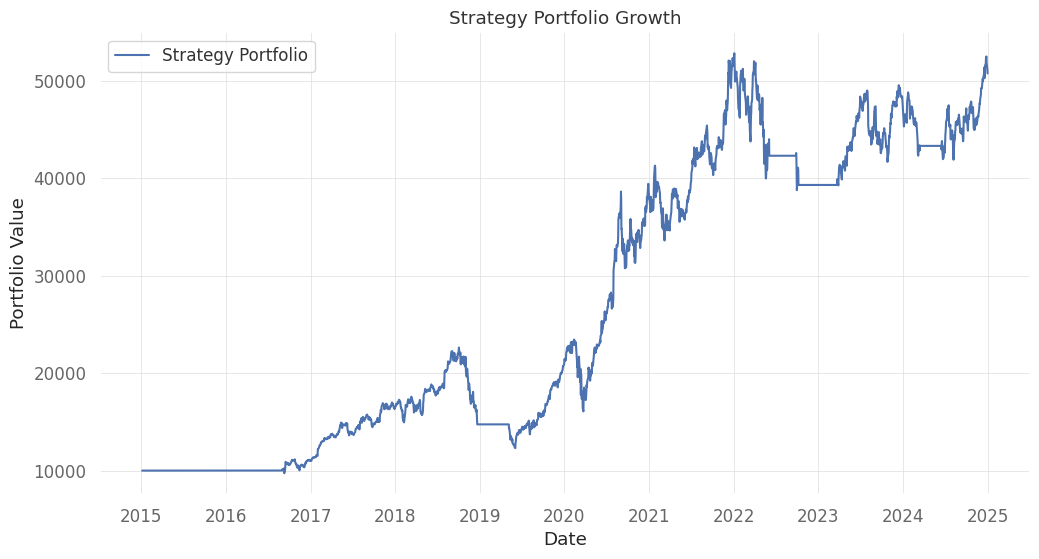

In [14]:
# Plot Portfolio Performance

plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Strategy Portfolio"
)

plt.title("Strategy Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# 9. Benchmark Comparison

This section compares the trading strategy against a simple buy-and-hold approach.

In [15]:
# Calculate Buy and Hold Performance

data["Buy_Hold_Value"] = (
    10000 *
    (1 + data["Returns"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
Date,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977


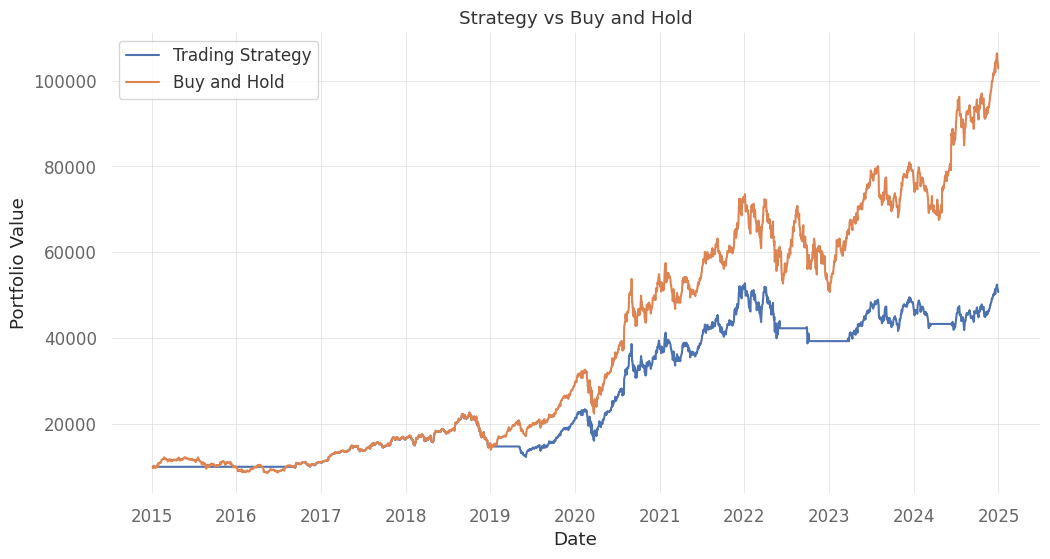

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Trading Strategy"
)

plt.plot(
    data.index,
    data["Buy_Hold_Value"],
    label="Buy and Hold"
)

plt.title("Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# 10. Performance Analysis

This section calculates risk-adjusted performance metrics used by professional investors to evaluate trading strategies.

In [17]:
# Calculate Performance Metrics

strategy_returns = data["Strategy_Returns"].dropna()

# Total Return
total_return = (
    data["Portfolio_Value"].iloc[-1] / 10000
) - 1

# CAGR
years = (
    data.index[-1] - data.index[0]
).days / 365.25

cagr = (
    data["Portfolio_Value"].iloc[-1] / 10000
) ** (1/years) - 1

# Volatility
volatility = strategy_returns.std() * np.sqrt(252)

# Sharpe Ratio
sharpe_ratio = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

print("Total Return:", round(total_return * 100, 2), "%")
print("CAGR:", round(cagr * 100, 2), "%")
print("Volatility:", round(volatility * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_ratio, 2))

Total Return: 407.27 %
CAGR: 17.64 %
Volatility: 23.64 %
Sharpe Ratio: 0.81


# 11. Risk Analysis

This section measures the downside risk of the trading strategy.

Maximum drawdown shows the largest percentage loss from a previous portfolio peak.

In [18]:
# Calculate Maximum Drawdown

data["Peak"] = data["Portfolio_Value"].cummax()

data["Drawdown"] = (
    data["Portfolio_Value"] - data["Peak"]
) / data["Peak"]

max_drawdown = data["Drawdown"].min()

print(
    "Maximum Drawdown:",
    round(max_drawdown * 100, 2),
    "%"
)

Maximum Drawdown: -45.61 %


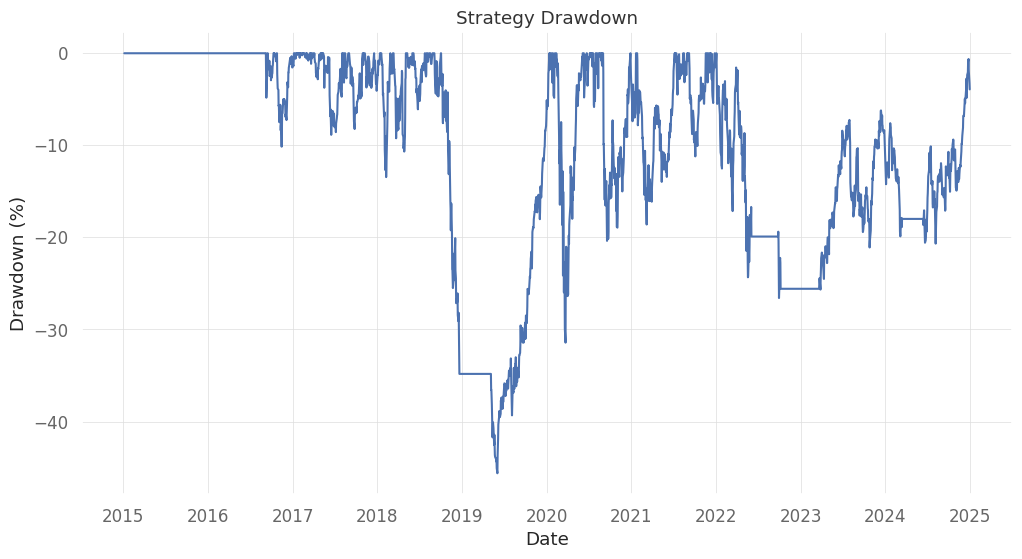

In [19]:
# Plot Drawdown

plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Drawdown"] * 100
)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.show()

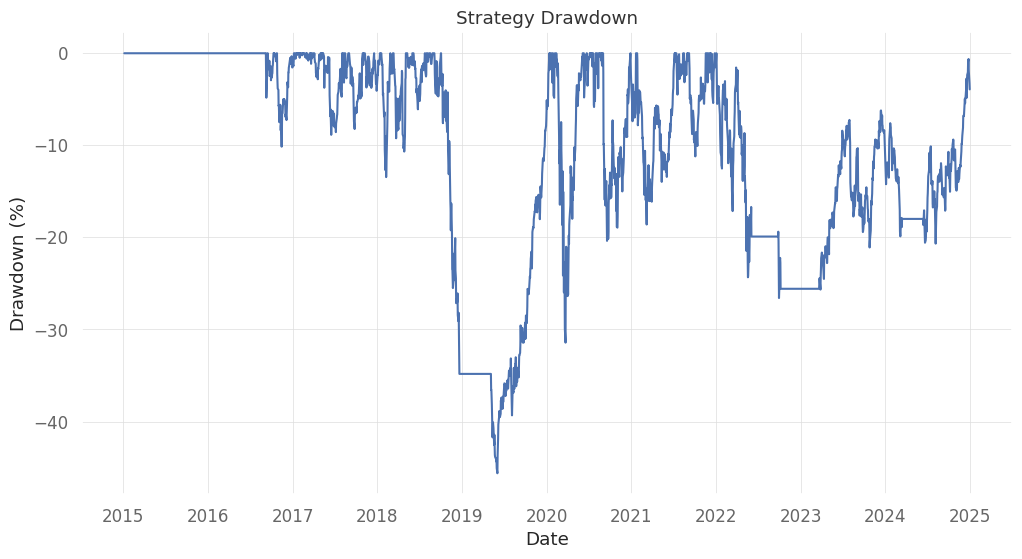

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Drawdown"] * 100
)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.show()

# 12. Transaction Cost Modeling

This section adds realistic trading costs to the backtest.

A 0.1% transaction cost is applied every time the strategy changes position.

In [21]:
# Add Transaction Costs

transaction_cost = 0.001  # 0.1%

# Detect trades
data["Trades"] = data["Signal"].diff().abs()

# Adjust returns
data["Strategy_Returns_Costs"] = (
    data["Strategy_Returns"] -
    (data["Trades"] * transaction_cost)
)

# Recalculate portfolio value

data["Portfolio_With_Costs"] = (
    10000 *
    (1 + data["Strategy_Returns_Costs"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


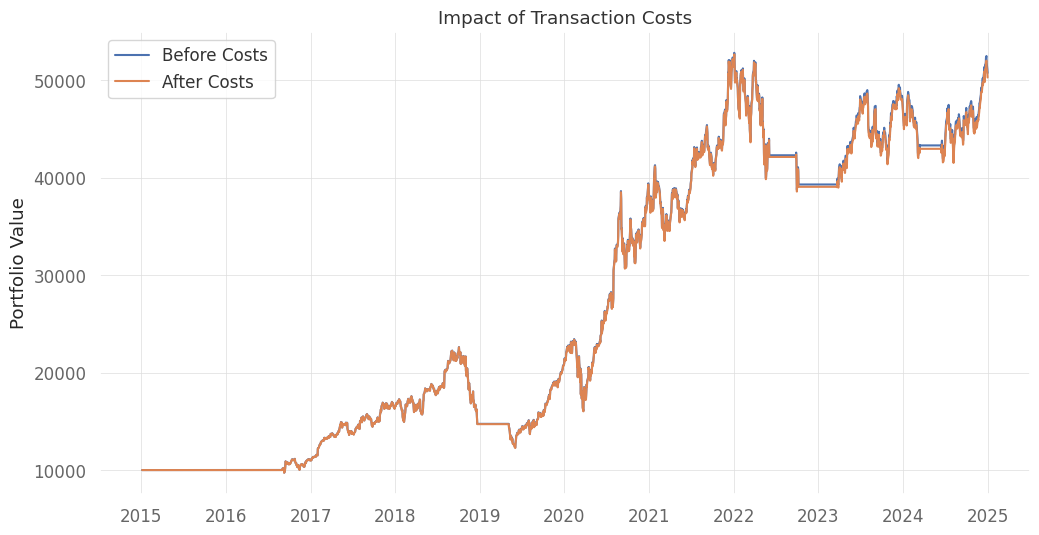

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Before Costs"
)

plt.plot(
    data.index,
    data["Portfolio_With_Costs"],
    label="After Costs"
)

plt.title("Impact of Transaction Costs")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# 12. Transaction Cost Modeling

This section adds realistic trading costs to the strategy by applying a fee every time the portfolio changes position.

In [23]:
# Add Transaction Costs

transaction_cost = 0.001  # 0.1%

data["Trades"] = data["Signal"].diff().abs()

data["Strategy_Returns_Costs"] = (
    data["Strategy_Returns"] -
    (data["Trades"] * transaction_cost)
)

data["Portfolio_With_Costs"] = (
    10000 *
    (1 + data["Strategy_Returns_Costs"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


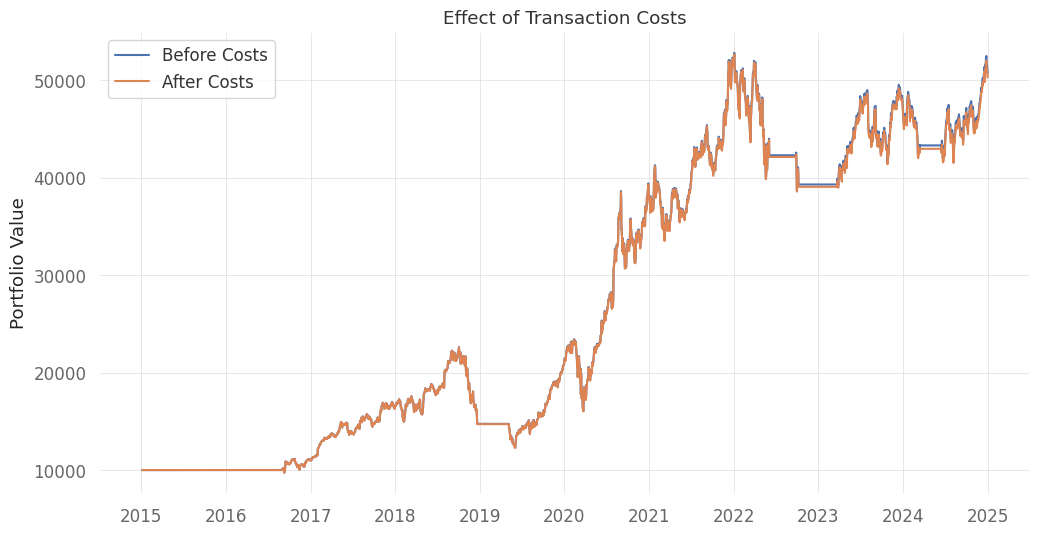

In [24]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Before Costs"
)

plt.plot(
    data.index,
    data["Portfolio_With_Costs"],
    label="After Costs"
)

plt.title("Effect of Transaction Costs")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

# 7. Trading Signal Generation

This section converts the moving average crossover into actual buy and sell decisions.

In [25]:
# Create Trading Signals

data["Signal"] = 0

data.loc[data["50_MA"] > data["200_MA"], "Signal"] = 1

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


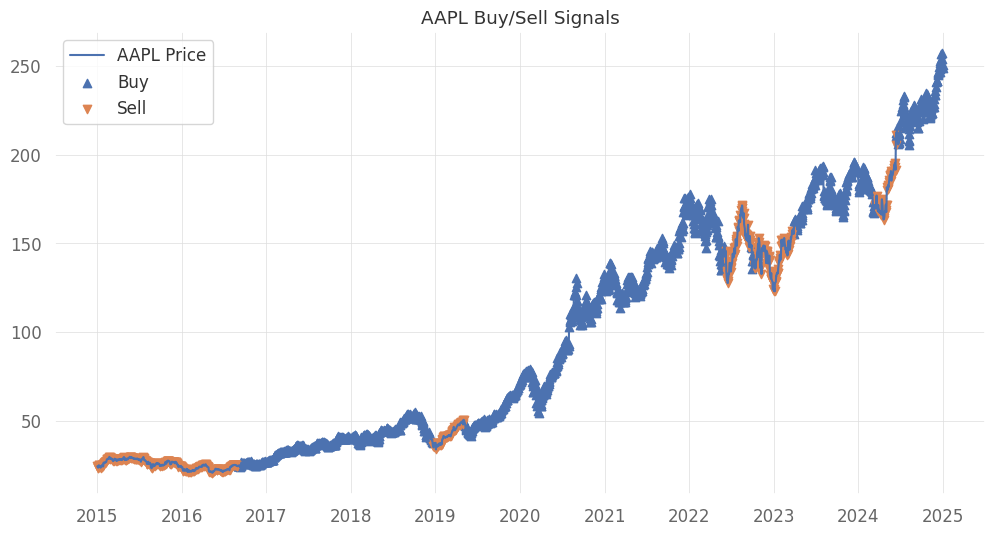

In [26]:
# Plot Trading Signals

plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="AAPL Price")

plt.scatter(
    data[data["Signal"] == 1].index,
    data[data["Signal"] == 1]["Close"],
    marker="^",
    label="Buy"
)

plt.scatter(
    data[data["Signal"] == 0].index,
    data[data["Signal"] == 0]["Close"],
    marker="v",
    label="Sell"
)

plt.title("AAPL Buy/Sell Signals")
plt.legend()
plt.show()

# 5. Data Cleaning and Preparation

This section prepares the historical stock data for analysis by checking for missing values and ensuring the dataset is ready for strategy development.

In [27]:
# Check dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   (Close, AAPL)               2516 non-null   float64
 1   (High, AAPL)                2516 non-null   float64
 2   (Low, AAPL)                 2516 non-null   float64
 3   (Open, AAPL)                2516 non-null   float64
 4   (Volume, AAPL)              2516 non-null   int64  
 5   (50_MA, )                   2467 non-null   float64
 6   (200_MA, )                  2317 non-null   float64
 7   (Signal, )                  2516 non-null   int64  
 8   (Returns, )                 2515 non-null   float64
 9   (Strategy_Returns, )        2515 non-null   float64
 10  (Portfolio_Value, )         2515 non-null   float64
 11  (Buy_Hold_Value, )          2515 non-null   float64
 12  (Peak, )                    2515 non-null   float64
 13  (Drawdown, )   

In [28]:
# Check for missing values

data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0
50_MA,,49
200_MA,,199
Signal,,0
Returns,,1


# 5. Data Cleaning and Preparation

This section prepares the historical stock data for analysis by checking for missing values and ensuring the dataset is ready for strategy development.

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   (Close, AAPL)               2516 non-null   float64
 1   (High, AAPL)                2516 non-null   float64
 2   (Low, AAPL)                 2516 non-null   float64
 3   (Open, AAPL)                2516 non-null   float64
 4   (Volume, AAPL)              2516 non-null   int64  
 5   (50_MA, )                   2467 non-null   float64
 6   (200_MA, )                  2317 non-null   float64
 7   (Signal, )                  2516 non-null   int64  
 8   (Returns, )                 2515 non-null   float64
 9   (Strategy_Returns, )        2515 non-null   float64
 10  (Portfolio_Value, )         2515 non-null   float64
 11  (Buy_Hold_Value, )          2515 non-null   float64
 12  (Peak, )                    2515 non-null   float64
 13  (Drawdown, )   

In [30]:
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0
50_MA,,49
200_MA,,199
Signal,,0
Returns,,1


In [32]:
data = data.dropna()

# 6. Strategy Development

This section creates a moving average crossover strategy.

The strategy compares short-term momentum (50-day moving average) with long-term momentum (200-day moving average) to identify potential buy signals.

In [33]:
# Create Moving Averages

data["50_MA"] = data["Close"].rolling(window=50).mean()

data["200_MA"] = data["Close"].rolling(window=200).mean()

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,NaN,NaN,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,NaN,NaN,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,NaN,NaN,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,NaN,NaN,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,NaN,NaN,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


In [37]:
# Create Moving Averages

data["50_MA"] = data["Close"].rolling(window=50).mean()

data["200_MA"] = data["Close"].rolling(window=200).mean()

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


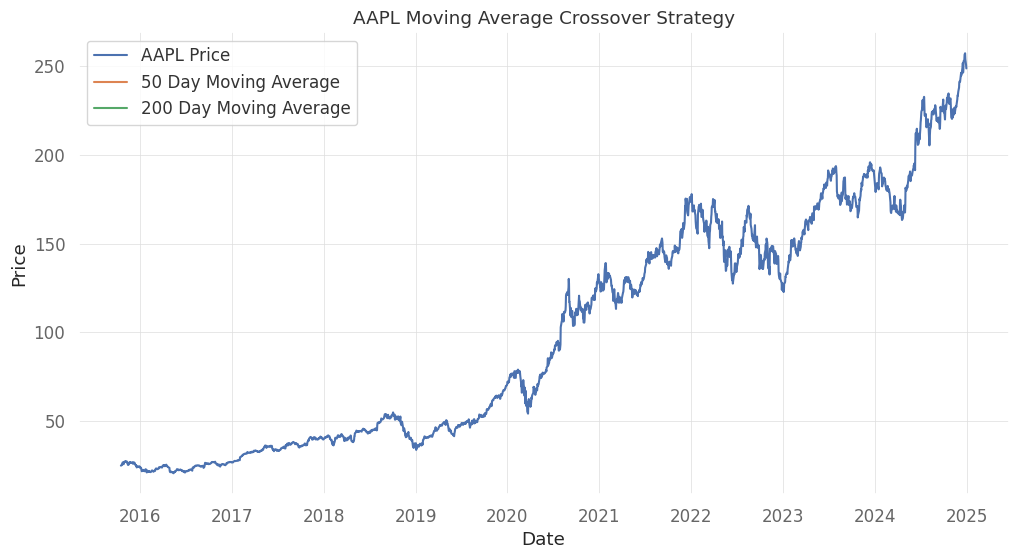

In [35]:
# Plot Moving Averages

plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="AAPL Price")
plt.plot(data["50_MA"], label="50 Day Moving Average")
plt.plot(data["200_MA"], label="200 Day Moving Average")

plt.title("AAPL Moving Average Crossover Strategy")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [36]:
# Fix Yahoo Finance column structure

data.columns = data.columns.droplevel(1)

data.head()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2015-10-16,24.883133,25.098261,24.768846,25.048960,156930400,NaN,NaN,0,-0.007330,-0.0,10000.0,10285.429740,10000.0,0.0,0.0,-0.0,10000.0
2015-10-19,25.037756,25.042237,24.674727,24.829351,119036800,NaN,NaN,0,0.006214,0.0,10000.0,10349.343088,10000.0,0.0,0.0,0.0,10000.0
2015-10-20,25.494900,25.584537,24.833830,24.950357,195871200,NaN,NaN,0,0.018258,0.0,10000.0,10538.303227,10000.0,0.0,0.0,0.0,10000.0
2015-10-21,25.492662,25.900509,25.479216,25.546444,167180800,NaN,NaN,0,-0.000088,-0.0,10000.0,10537.378432,10000.0,0.0,0.0,-0.0,10000.0
2015-10-22,25.882580,25.882580,25.568851,25.620393,166616400,NaN,NaN,0,0.015295,0.0,10000.0,10698.550571,10000.0,0.0,0.0,0.0,10000.0


In [38]:
data["50_MA"] = data["Close"].rolling(window=50).mean()

data["200_MA"] = data["Close"].rolling(window=200).mean()

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


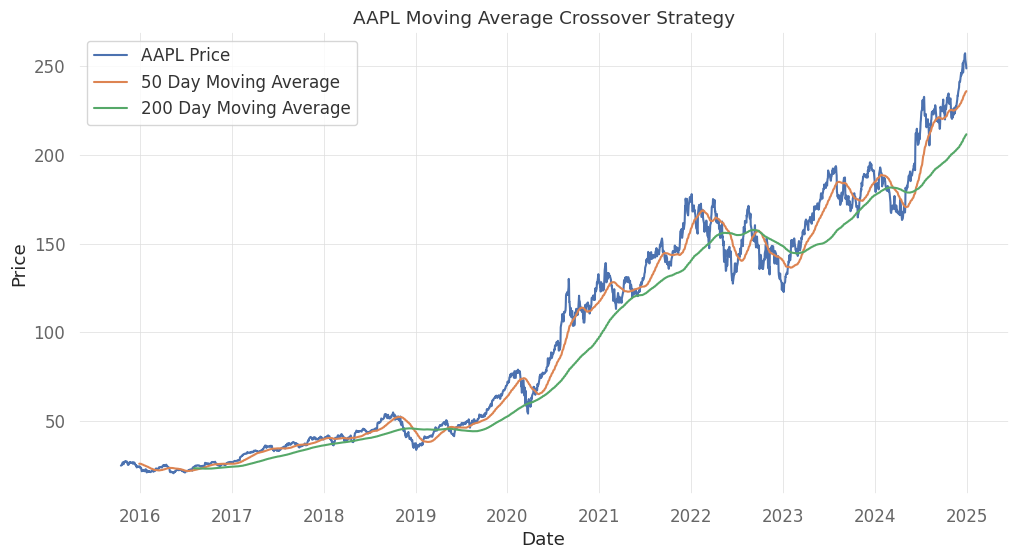

In [39]:
# Plot Moving Averages

plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="AAPL Price")
plt.plot(data["50_MA"], label="50 Day Moving Average")
plt.plot(data["200_MA"], label="200 Day Moving Average")

plt.title("AAPL Moving Average Crossover Strategy")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [40]:
# Create Trading Signals

data["Signal"] = 0

data.loc[data["50_MA"] > data["200_MA"], "Signal"] = 1

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


In [41]:
# Calculate Daily Returns

data["Returns"] = data["Close"].pct_change()

data.head()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2015-10-16,24.883133,25.098261,24.768846,25.048960,156930400,NaN,NaN,0,NaN,-0.0,10000.0,10285.429740,10000.0,0.0,0.0,-0.0,10000.0
2015-10-19,25.037756,25.042237,24.674727,24.829351,119036800,NaN,NaN,0,0.006214,0.0,10000.0,10349.343088,10000.0,0.0,0.0,0.0,10000.0
2015-10-20,25.494900,25.584537,24.833830,24.950357,195871200,NaN,NaN,0,0.018258,0.0,10000.0,10538.303227,10000.0,0.0,0.0,0.0,10000.0
2015-10-21,25.492662,25.900509,25.479216,25.546444,167180800,NaN,NaN,0,-0.000088,-0.0,10000.0,10537.378432,10000.0,0.0,0.0,-0.0,10000.0
2015-10-22,25.882580,25.882580,25.568851,25.620393,166616400,NaN,NaN,0,0.015295,0.0,10000.0,10698.550571,10000.0,0.0,0.0,0.0,10000.0


In [42]:
# Calculate Strategy Returns

data["Strategy_Returns"] = (
    data["Signal"].shift(1) *
    data["Returns"]
)

data.head()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2015-10-16,24.883133,25.098261,24.768846,25.048960,156930400,NaN,NaN,0,NaN,NaN,10000.0,10285.429740,10000.0,0.0,0.0,-0.0,10000.0
2015-10-19,25.037756,25.042237,24.674727,24.829351,119036800,NaN,NaN,0,0.006214,0.0,10000.0,10349.343088,10000.0,0.0,0.0,0.0,10000.0
2015-10-20,25.494900,25.584537,24.833830,24.950357,195871200,NaN,NaN,0,0.018258,0.0,10000.0,10538.303227,10000.0,0.0,0.0,0.0,10000.0
2015-10-21,25.492662,25.900509,25.479216,25.546444,167180800,NaN,NaN,0,-0.000088,-0.0,10000.0,10537.378432,10000.0,0.0,0.0,-0.0,10000.0
2015-10-22,25.882580,25.882580,25.568851,25.620393,166616400,NaN,NaN,0,0.015295,0.0,10000.0,10698.550571,10000.0,0.0,0.0,0.0,10000.0


# 9. Portfolio Backtesting

This section simulates investing $10,000 using the trading strategy and tracks portfolio growth over time.

In [43]:
# Starting investment

initial_investment = 10000

data["Portfolio_Value"] = (
    initial_investment *
    (1 + data["Strategy_Returns"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,106049.278881,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,106386.058790,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,104977.286152,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,103584.918572,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,102853.836977,52799.557898,-0.039253,0.0,-0.007058,50266.890330


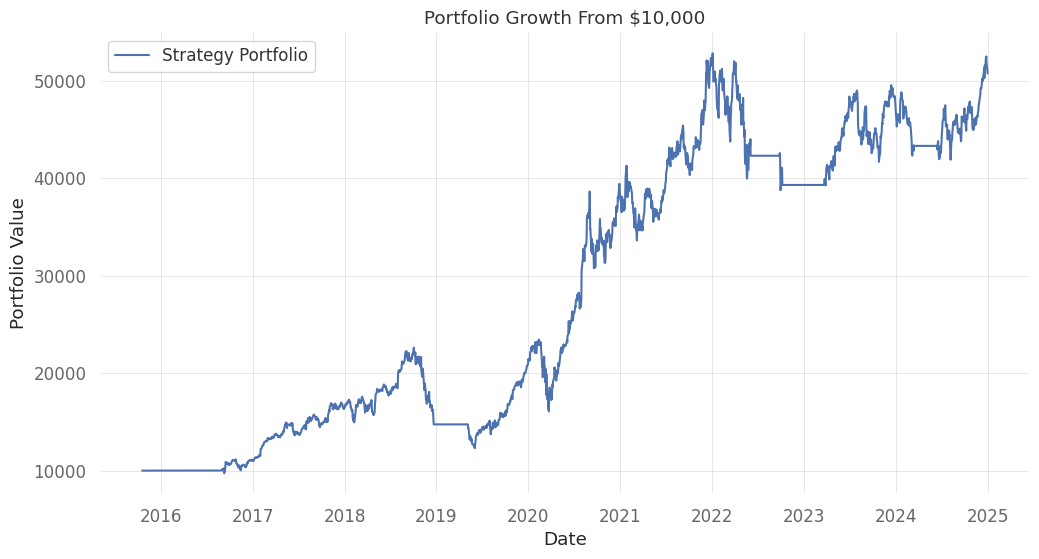

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Strategy Portfolio"
)

plt.title("Portfolio Growth From $10,000")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

In [45]:
# Calculate Buy and Hold Performance

data["Buy_Hold_Value"] = (
    10000 *
    (1 + data["Returns"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,103106.317925,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,103433.751896,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,102064.073939,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,100710.345788,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,99999.552351,52799.557898,-0.039253,0.0,-0.007058,50266.890330


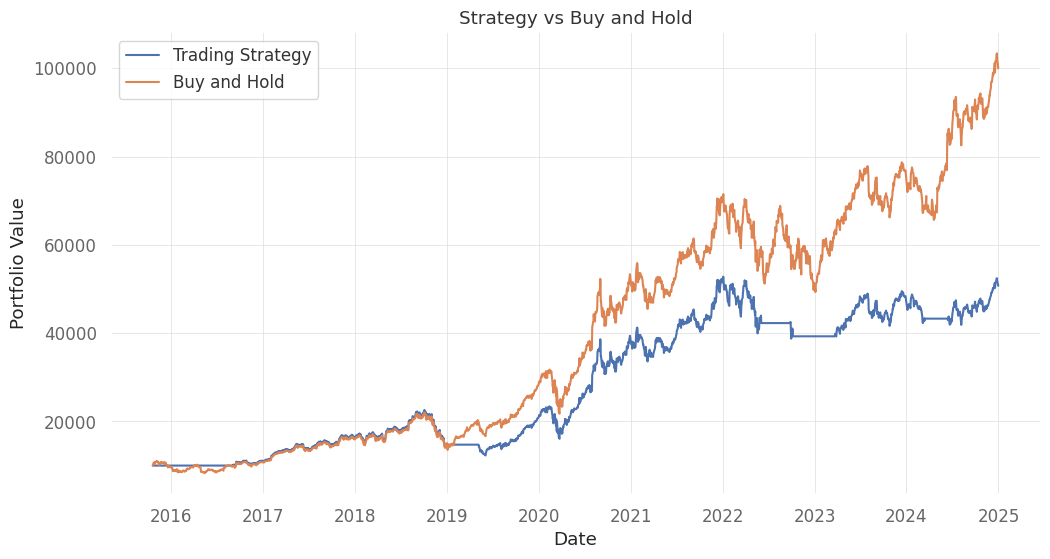

In [46]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Trading Strategy"
)

plt.plot(
    data.index,
    data["Buy_Hold_Value"],
    label="Buy and Hold"
)

plt.title("Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# 10. Performance Analysis

This section calculates risk-adjusted metrics used to evaluate the strategy.

In [47]:
# Performance Metrics

strategy_returns = data["Strategy_Returns"].dropna()

total_return = (
    data["Portfolio_Value"].iloc[-1] / 10000
) - 1

years = (
    data.index[-1] - data.index[0]
).days / 365.25

cagr = (
    data["Portfolio_Value"].iloc[-1] / 10000
) ** (1/years) - 1

volatility = strategy_returns.std() * np.sqrt(252)

sharpe_ratio = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

print("Total Return:", round(total_return*100,2), "%")
print("CAGR:", round(cagr*100,2), "%")
print("Volatility:", round(volatility*100,2), "%")
print("Sharpe Ratio:", round(sharpe_ratio,2))

Total Return: 407.27 %
CAGR: 19.28 %
Volatility: 24.63 %
Sharpe Ratio: 0.84


In [48]:
# Calculate Maximum Drawdown

data["Peak"] = data["Portfolio_Value"].cummax()

data["Drawdown"] = (
    data["Portfolio_Value"] - data["Peak"]
) / data["Peak"]

max_drawdown = data["Drawdown"].min()

print("Maximum Drawdown:", round(max_drawdown*100,2), "%")

Maximum Drawdown: -45.61 %


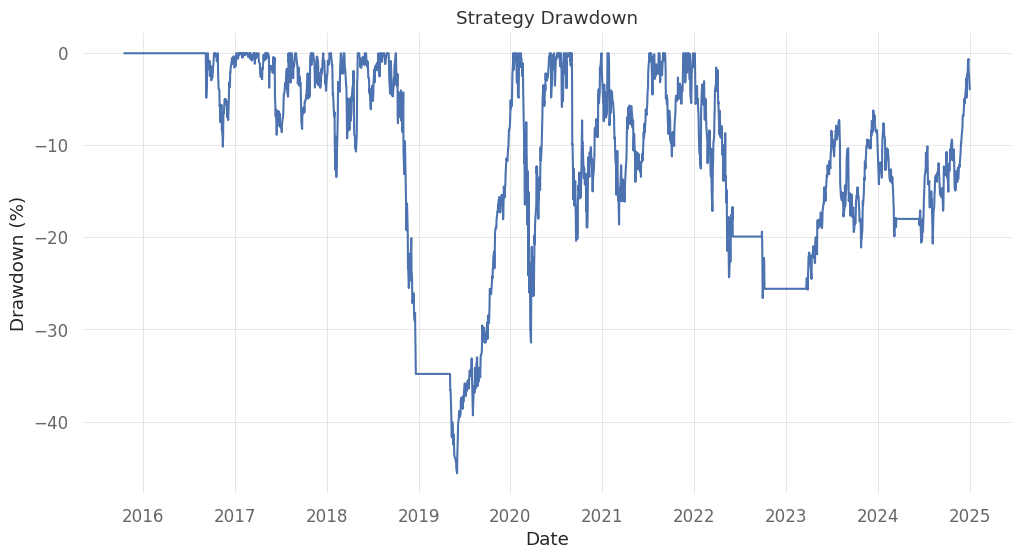

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Drawdown"] * 100
)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.show()

In [50]:
# Add Transaction Costs

transaction_cost = 0.001  # 0.1% per trade

data["Trades"] = data["Signal"].diff().abs()

data["Strategy_Returns_Costs"] = (
    data["Strategy_Returns"] -
    (data["Trades"] * transaction_cost)
)

data["Portfolio_With_Costs"] = (
    10000 *
    (1 + data["Strategy_Returns_Costs"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,103106.317925,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,103433.751896,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,102064.073939,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,100710.345788,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,99999.552351,52799.557898,-0.039253,0.0,-0.007058,50266.890330


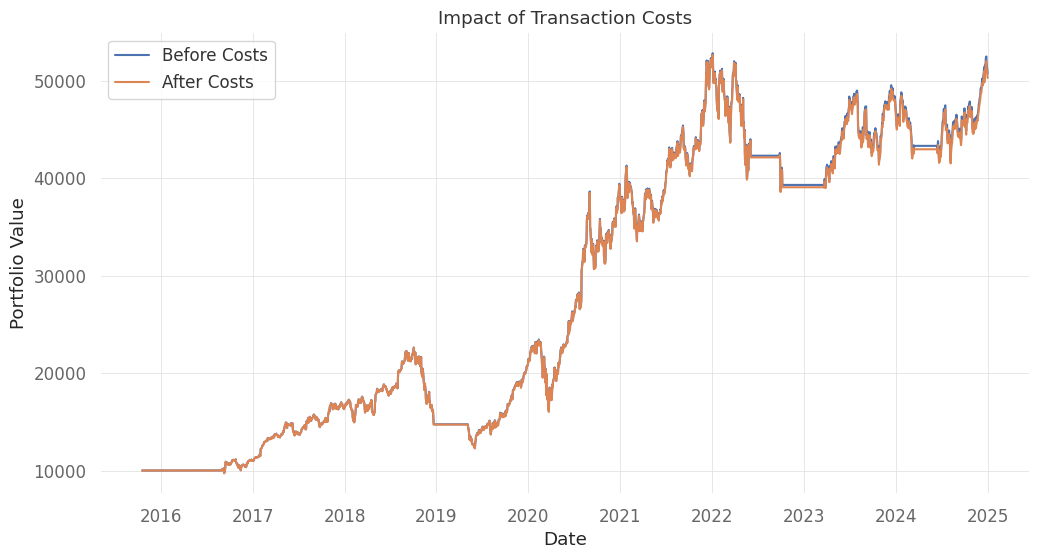

In [51]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Before Costs"
)

plt.plot(
    data.index,
    data["Portfolio_With_Costs"],
    label="After Costs"
)

plt.title("Impact of Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

In [52]:
# Add Transaction Costs

transaction_cost = 0.001  # 0.1%

data["Trades"] = data["Signal"].diff().abs()

data["Strategy_Returns_Costs"] = (
    data["Strategy_Returns"] -
    (data["Trades"] * transaction_cost)
)

data["Portfolio_With_Costs"] = (
    10000 *
    (1 + data["Strategy_Returns_Costs"]).cumprod()
)

data.tail()

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs
Date,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,103106.317925,52799.557898,-0.009404,0.0,0.011478,51828.571766
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,103433.751896,52799.557898,-0.006258,0.0,0.003176,51993.163377
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,102064.073939,52799.557898,-0.019418,0.0,-0.013242,51304.665779
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,100710.345788,52799.557898,-0.032424,0.0,-0.013264,50624.185687
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,99999.552351,52799.557898,-0.039253,0.0,-0.007058,50266.890330


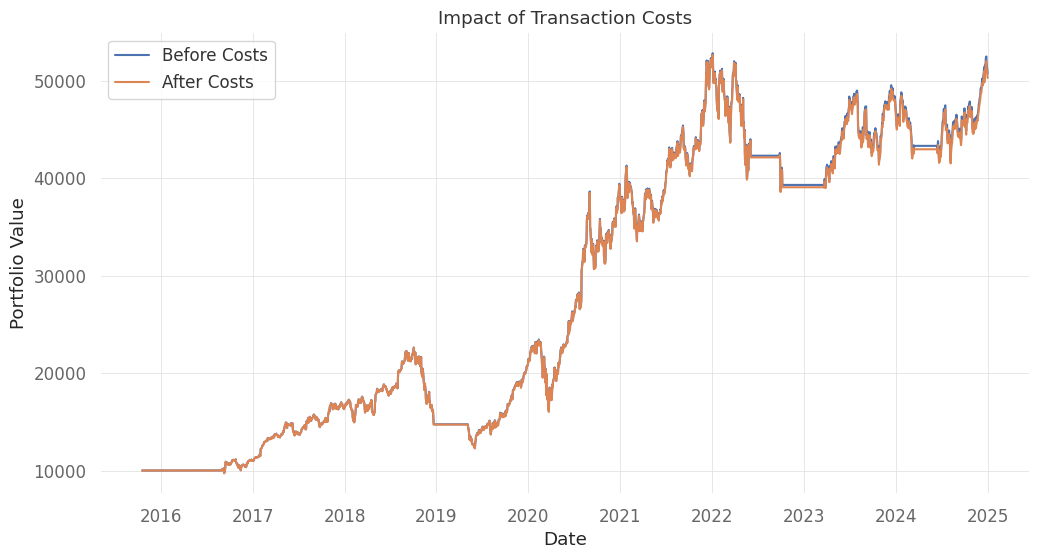

In [53]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Portfolio_Value"],
    label="Before Costs"
)

plt.plot(
    data.index,
    data["Portfolio_With_Costs"],
    label="After Costs"
)

plt.title("Impact of Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# 13. Walk-Forward Validation

This section tests the strategy on separate training and testing periods to reduce overfitting and evaluate real-world performance.

In [54]:
# Split data into training and testing periods

split_date = "2021-01-01"

train = data[data.index < split_date]

test = data[data.index >= split_date]

print("Training Period:", train.index[0], "to", train.index[-1])
print("Testing Period:", test.index[0], "to", test.index[-1])

Training Period: 2015-10-16 00:00:00 to 2020-12-31 00:00:00
Testing Period: 2021-01-04 00:00:00 to 2024-12-31 00:00:00


In [55]:
# Run strategy on unseen testing data

test["Test_Returns"] = test["Returns"]

test["Test_Strategy_Returns"] = (
    test["Signal"].shift(1) *
    test["Test_Returns"]
)

test["Test_Portfolio_Value"] = (
    10000 *
    (1 + test["Test_Strategy_Returns"]).cumprod()
)

test.tail()

/tmp/ipykernel_1906/3119394963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Test_Returns"] = test["Returns"]
/tmp/ipykernel_1906/3119394963.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Test_Strategy_Returns"] = (
/tmp/ipykernel_1906/3119394963.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs,Test_Returns,Test_Strategy_Returns,Test_Portfolio_Value
Date,,,,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,103106.317925,52799.557898,-0.009404,0.0,0.011478,51828.571766,0.011478,0.011478,14018.221192
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,103433.751896,52799.557898,-0.006258,0.0,0.003176,51993.163377,0.003176,0.003176,14062.738753
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,102064.073939,52799.557898,-0.019418,0.0,-0.013242,51304.665779,-0.013242,-0.013242,13876.518850
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,100710.345788,52799.557898,-0.032424,0.0,-0.013264,50624.185687,-0.013264,-0.013264,13692.467464
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,99999.552351,52799.557898,-0.039253,0.0,-0.007058,50266.890330,-0.007058,-0.007058,13595.828773


In [56]:
# Run strategy on unseen testing data

test["Test_Strategy_Returns"] = (
    test["Signal"].shift(1) *
    test["Returns"]
)

test["Test_Portfolio_Value"] = (
    10000 *
    (1 + test["Test_Strategy_Returns"]).cumprod()
)

test.tail()

/tmp/ipykernel_1906/642062968.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Test_Strategy_Returns"] = (
/tmp/ipykernel_1906/642062968.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Test_Portfolio_Value"] = (


Price,Close,High,Low,Open,Volume,50_MA,200_MA,Signal,Returns,Strategy_Returns,Portfolio_Value,Buy_Hold_Value,Peak,Drawdown,Trades,Strategy_Returns_Costs,Portfolio_With_Costs,Test_Returns,Test_Strategy_Returns,Test_Portfolio_Value
Date,,,,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,234.325891,210.072595,1,0.011478,0.011478,52303.017729,103106.317925,52799.557898,-0.009404,0.0,0.011478,51828.571766,0.011478,0.011478,14018.221192
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,234.831201,210.501925,1,0.003176,0.003176,52469.116035,103433.751896,52799.557898,-0.006258,0.0,0.003176,51993.163377,0.003176,0.003176,14062.738753
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,235.309441,210.924609,1,-0.013242,-0.013242,51774.315834,102064.073939,52799.557898,-0.019418,0.0,-0.013242,51304.665779,-0.013242,-0.013242,13876.518850
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,235.712965,211.321194,1,-0.013264,-0.013264,51087.606533,100710.345788,52799.557898,-0.032424,0.0,-0.013264,50624.185687,-0.013264,-0.013264,13692.467464
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700,236.024540,211.710816,1,-0.007058,-0.007058,50727.040445,99999.552351,52799.557898,-0.039253,0.0,-0.007058,50266.890330,-0.007058,-0.007058,13595.828773


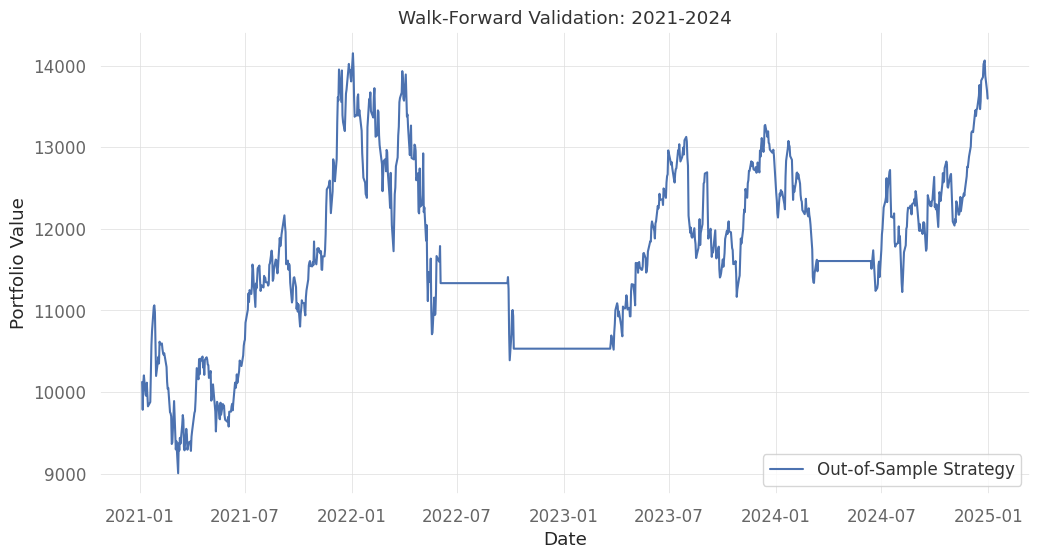

In [57]:
# Plot Walk-Forward Test Results

plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    test["Test_Portfolio_Value"],
    label="Out-of-Sample Strategy"
)

plt.title("Walk-Forward Validation: 2021-2024")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

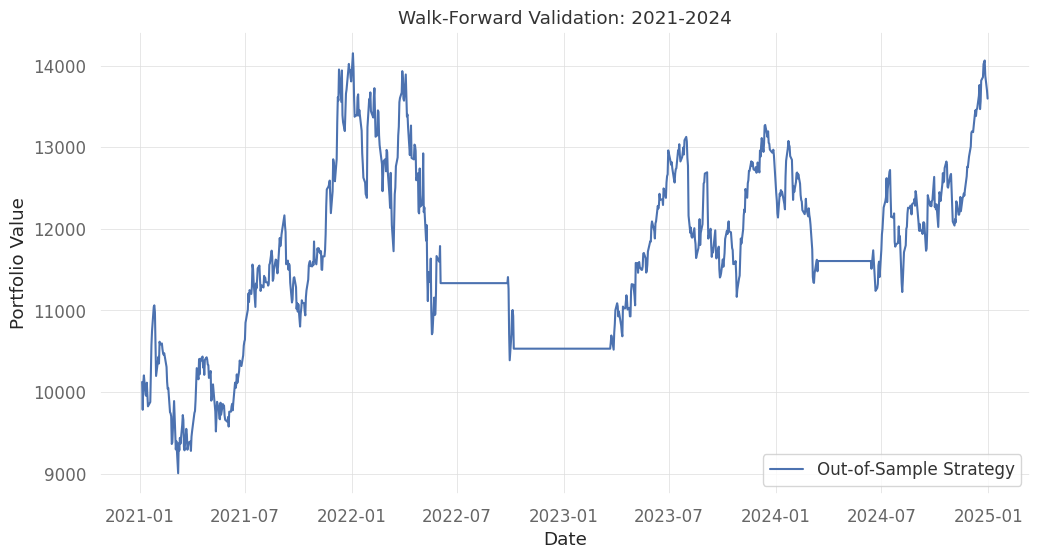

In [59]:
plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    test["Test_Portfolio_Value"],
    label="Out-of-Sample Strategy"
)

plt.title("Walk-Forward Validation: 2021-2024")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

In [60]:
# Out-of-Sample Metrics

test_total_return = (
    test["Test_Portfolio_Value"].iloc[-1] / 10000
) - 1

test_years = (
    test.index[-1] - test.index[0]
).days / 365.25

test_cagr = (
    test["Test_Portfolio_Value"].iloc[-1] / 10000
) ** (1/test_years) - 1

test_volatility = (
    test["Test_Strategy_Returns"].std()
    * np.sqrt(252)
)

test_sharpe = (
    test["Test_Strategy_Returns"].mean()
    /
    test["Test_Strategy_Returns"].std()
) * np.sqrt(252)

print("Test Total Return:", round(test_total_return*100,2), "%")
print("Test CAGR:", round(test_cagr*100,2), "%")
print("Test Volatility:", round(test_volatility*100,2), "%")
print("Test Sharpe Ratio:", round(test_sharpe,2))

Test Total Return: 35.96 %
Test CAGR: 8.0 %
Test Volatility: 21.29 %
Test Sharpe Ratio: 0.47


/tmp/ipykernel_1906/3838951179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Buy_Hold_Test_Value"] = (


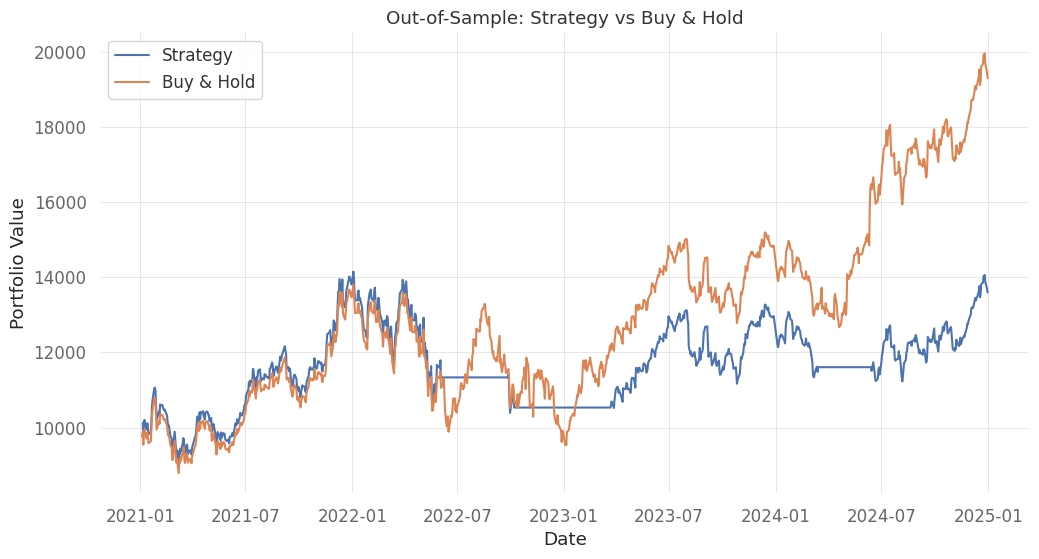

In [61]:
test["Buy_Hold_Test_Value"] = (
    10000 *
    (1 + test["Returns"]).cumprod()
)

plt.figure(figsize=(12,6))

plt.plot(test.index, test["Test_Portfolio_Value"], label="Strategy")
plt.plot(test.index, test["Buy_Hold_Test_Value"], label="Buy & Hold")

plt.title("Out-of-Sample: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# Final Results and Findings

## Strategy Overview

This project developed and evaluated a moving average crossover trading strategy using historical AAPL stock data from 2015 to 2024. The strategy used a 50-day moving average and a 200-day moving average to generate buy and sell signals.

## Backtesting Results

The strategy was initially tested on the full dataset with a starting portfolio value of $10,000. The backtest produced:

* Total Return: 407.27%
* CAGR: 19.28%
* Volatility: 24.63%
* Sharpe Ratio: 0.84
* Maximum Drawdown: approximately -45%

The results showed that the strategy was profitable historically but experienced significant periods of risk and drawdown.

## Out-of-Sample Validation

To reduce overfitting, a walk-forward validation approach was used. The model was trained on data from 2015–2020 and tested on unseen data from 2021–2024.

The out-of-sample results were:

* Total Return: 35.96%
* CAGR: 8.00%
* Volatility: 21.29%
* Sharpe Ratio: 0.47

The strategy remained profitable during the testing period, demonstrating that the approach was able to generate returns on unseen market data.

## Key Findings

The moving average crossover strategy successfully identified long-term market trends and generated positive returns. However, when compared with a simple buy-and-hold strategy, the strategy did not consistently outperform passive investing.

The main limitation of the strategy is that it can react slowly to sudden market changes and may miss large price movements. Additionally, transaction costs and periods of high volatility can reduce performance.

## Conclusion

This project demonstrates the process of building, testing, and evaluating a quantitative trading strategy. While the strategy was profitable, further improvements such as volatility filtering, additional factors, and machine learning-based signals could potentially improve risk-adjusted performance.
